# Pandas Merging, Joining & Concatenation

## Introduction

In real-world data analysis, information is rarely stored in a single dataset. Instead, it is distributed across multiple DataFrames or database tables. To analyze such data effectively, we need to combine these DataFrames.

Pandas provides three primary methods for combining data:

1. **merge()** – Combines DataFrames using one or more common columns (similar to SQL JOIN).
2. **join()** – Combines DataFrames primarily using their indexes.
3. **concat()** – Stacks DataFrames either vertically or horizontally.

Choosing the appropriate method depends on the structure of your data and the desired output.

---

# 1. DataFrame Merge (`pd.merge()`)

## What is Merge?

`merge()` combines two DataFrames by matching values in one or more common columns.

It works similarly to SQL JOIN operations and is the most commonly used method for combining relational datasets.

### Syntax

```python
pd.merge(
    left,
    right,
    how='inner',
    on=None,
    left_on=None,
    right_on=None,
    left_index=False,
    right_index=False,
    sort=False,
    suffixes=('_x', '_y'),
    copy=None,
    indicator=False,
    validate=None
)
```

---

# Parameters

| Parameter | Description |
|-----------|-------------|
| `left` | Left DataFrame |
| `right` | Right DataFrame |
| `on` | Common column(s) used for matching |
| `how` | Type of merge |
| `left_on` | Column(s) from left DataFrame |
| `right_on` | Column(s) from right DataFrame |
| `left_index` | Use left index as key |
| `right_index` | Use right index as key |
| `sort` | Sort merge keys |
| `suffixes` | Rename duplicate columns |
| `indicator` | Shows merge source |
| `validate` | Validates merge relationship |

---

# Sample Data

```python
import pandas as pd

students = pd.DataFrame({
    "ID":[101,102,103,104],
    "Name":["Ali","Sara","Ahmed","Ayesha"]
})

marks = pd.DataFrame({
    "ID":[101,103,104,105],
    "Marks":[88,91,76,95]
})
```

---

# 2. Inner Join

Returns only matching records from both DataFrames.

```python
pd.merge(students, marks, on="ID", how="inner")
```

### Output

| ID | Name | Marks |
|----|------|------|
|101|Ali|88|
|103|Ahmed|91|
|104|Ayesha|76|

**Explanation**

- Keeps only common IDs.
- Unmatched rows are removed.

---

# 3. Left Join

Returns every row from the left DataFrame.

```python
pd.merge(students, marks, on="ID", how="left")
```

### Output

| ID | Name | Marks |
|----|------|------|
|101|Ali|88|
|102|Sara|NaN|
|103|Ahmed|91|
|104|Ayesha|76|

**Explanation**

- Every student appears.
- Missing marks become `NaN`.

---

# 4. Right Join

Returns every row from the right DataFrame.

```python
pd.merge(students, marks, on="ID", how="right")
```

### Output

| ID | Name | Marks |
|----|------|------|
|101|Ali|88|
|103|Ahmed|91|
|104|Ayesha|76|
|105|NaN|95|

---

# 5. Outer Join

Returns all rows from both DataFrames.

```python
pd.merge(students, marks, on="ID", how="outer")
```

### Output

| ID | Name | Marks |
|----|------|------|
|101|Ali|88|
|102|Sara|NaN|
|103|Ahmed|91|
|104|Ayesha|76|
|105|NaN|95|

---

# 6. Cross Join

Creates every possible combination.

```python
pd.merge(students, marks, how="cross")
```

If

- Students = 4 rows
- Marks = 4 rows

Output:

```
4 × 4 = 16 rows
```

Use Cases

- Recommendation systems
- Simulations
- Product combinations

---

# 7. Merge on Multiple Columns

When a single column cannot uniquely identify records.

```python
employees = pd.DataFrame({
    "ID":[1,1,2],
    "Department":["IT","HR","IT"],
    "Salary":[50000,45000,55000]
})

bonus = pd.DataFrame({
    "ID":[1,2],
    "Department":["IT","IT"],
    "Bonus":[5000,7000]
})

pd.merge(
    employees,
    bonus,
    on=["ID","Department"]
)
```

---

# 8. Different Column Names

Suppose

Students

```text
Student_ID
```

Marks

```text
ID
```

```python
pd.merge(
    students,
    marks,
    left_on="Student_ID",
    right_on="ID"
)
```

---

# 9. Duplicate Column Names

Suppose both DataFrames contain

```
Name
Age
```

Pandas automatically creates

```
Name_x
Name_y
```

You can customize them.

```python
pd.merge(
    df1,
    df2,
    on="ID",
    suffixes=("_Student","_Teacher")
)
```

---

# 10. Merge Indicator

Shows where each row originated.

```python
pd.merge(
    students,
    marks,
    on="ID",
    how="outer",
    indicator=True
)
```

### Output

| ID | Name | Marks | _merge |
|----|------|------|---------|
|101|Ali|88|both|
|102|Sara|NaN|left_only|
|105|NaN|95|right_only|

Useful for:

- Finding missing records
- Debugging merges
- Data validation

---

# 11. Merge Validation

Checks whether relationships are correct.

```python
pd.merge(
    df1,
    df2,
    on="ID",
    validate="one_to_one"
)
```

Possible values

- `"one_to_one"`
- `"one_to_many"`
- `"many_to_one"`
- `"many_to_many"`

---

# 12. Merge Using Index

Instead of columns, merge using indexes.

```python
pd.merge(
    df1,
    df2,
    left_index=True,
    right_index=True
)
```

Useful when indexes already represent unique IDs.

---

# 13. DataFrame Join (`join()`)

## What is Join?

`join()` combines DataFrames using their indexes.

It is simpler than `merge()` when indexes are already aligned.

### Syntax

```python
df1.join(
    df2,
    how="left",
    lsuffix="_left",
    rsuffix="_right"
)
```

### Example

```python
students = students.set_index("ID")
marks = marks.set_index("ID")

students.join(marks)
```

### Output

| ID | Name | Marks |
|----|------|------|
|101|Ali|88|
|102|Sara|NaN|
|103|Ahmed|91|
|104|Ayesha|76|

---

# Join Types

`join()` supports

- left
- right
- inner
- outer

Example

```python
students.join(marks, how="inner")
```

---

# 14. Concatenation (`pd.concat()`)

## What is Concatenation?

`concat()` stacks DataFrames together.

Unlike `merge()`, it does **not** match rows using keys.

---

## Syntax

```python
pd.concat(
    objs,
    axis=0,
    ignore_index=False
)
```

---

# Vertical Concatenation

```python
df1 = pd.DataFrame({
    "Name":["Ali","Sara"]
})

df2 = pd.DataFrame({
    "Name":["Ahmed","Ayesha"]
})

pd.concat([df1, df2])
```

### Output

| Name |
|------|
|Ali|
|Sara|
|Ahmed|
|Ayesha|

---

# Horizontal Concatenation

```python
pd.concat([df1, df2], axis=1)
```

### Output

| Name | Name |
|------|------|
|Ali|Ahmed|
|Sara|Ayesha|

---

# Ignore Index

```python
pd.concat(
    [df1,df2],
    ignore_index=True
)
```

Output index becomes

```
0
1
2
3
```

---

# 15. Merge vs Join vs Concat

| Feature | merge() | join() | concat() |
|----------|----------|----------|-----------|
| Combines using common columns | ✅ | ❌ | ❌ |
| Uses indexes | Optional | ✅ | Optional |
| SQL-like joins | ✅ | Limited | ❌ |
| Stacks rows | ❌ | ❌ | ✅ |
| Stacks columns | ✅ | ✅ | ✅ |
| Most flexible | ✅ | Moderate | Simple |

---

# Best Practices

- Always verify key columns before merging.
- Remove duplicate keys if they are unintended.
- Use meaningful suffixes when duplicate column names exist.
- Check for missing values after merging.
- Use `validate` to prevent incorrect joins.
- Use `join()` when indexes are meaningful.
- Use `concat()` when stacking DataFrames rather than matching records.
- Inspect the output after every merge to ensure data integrity.

---

# Summary

- **`merge()`** combines DataFrames based on common column values and is ideal for SQL-style joins.
- **`join()`** combines DataFrames using indexes and offers a concise syntax for index-based operations.
- **`concat()`** appends DataFrames vertically or horizontally without matching keys.
- Understanding the differences between these methods is essential for data cleaning, preprocessing, feature engineering, and exploratory data analysis (EDA).

Mastering these techniques enables you to work efficiently with relational datasets and build reliable data analysis pipelines using Pandas.

In [133]:
import pandas as pd
import numpy as np 

In [134]:
students = pd.read_csv('students.csv')
nov = pd.read_csv('reg-month1.csv')
dec = pd.read_csv('reg-month2.csv')
matches = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')
courses = pd.read_csv('courses.csv')

# Datasets overview

In [4]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [5]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [7]:
dec

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [6]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [8]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [9]:
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


# pd.concat
# df.concat
# ignore_index
# df.append
# mullitindex -> fetch using iloc
# concat dataframes horizontally

In [26]:
# pd.concat   Vertically stack/merge the data 

regs = pd.concat([nov,dec],ignore_index=True) # both data frames merge vertically but it retain te indexes. ignore_inddex True avoid retaning
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [17]:
# multiline index usinf iloc

multi = pd.concat([nov,dec],keys=['nov','dec']) # make two indexes  as multi index nov or dec

In [18]:
multi

student_id  course_id
nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [ ]:
multi.loc['nov'] #fetching on multiline

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [23]:
multi.loc[('nov',0)]

student_id    23
course_id      1
Name: (nov, 0), dtype: int64

In [ ]:
# horizontal merging 
pd.concat([nov,dec],axis=1) # horizontal merging no of column not matter in horizontal merging 

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


# Merge

In [27]:
# inner join    #joining on one common column
students.merge(regs,how='inner',on='student_id') # first column become left table second table become right 
# In  how we tell wich join we want to perform inner outer full etc 
# in on we tell or give the common column



,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [30]:
# left join  # print all things of left tabel but just print common values from rigt tabel 
courses.merge(regs,how='left',on= 'course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [33]:
#Right join  # print all things of Right tabel but just print common values from left tabel 

temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Zain','Usman','hunain'],
    'partner':[28,26,17]
})

students = pd.concat([students,temp_df])

In [36]:
students.merge(regs, how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [38]:
students.merge(regs, how='left',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1.0
1,1,Kailash Harjo,23,6.0
2,1,Kailash Harjo,23,10.0
3,1,Kailash Harjo,23,9.0
4,2,Esha Butala,1,5.0
5,3,Parveen Bhalla,3,3.0
6,3,Parveen Bhalla,3,5.0
7,4,Marlo Dugal,14,NaN
8,5,Kusum Bahri,6,NaN
9,6,Lakshmi Contractor,10,NaN


In [41]:
# Full outer join Show all te data fro bot tables

students.merge(regs,how='outer',on='student_id').tail(10)

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Zain,28.0,NaN
58,27,Usman,26.0,NaN
59,28,hunain,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


In [ ]:
# 1. find total revenue generated
print("Total revenue by company is", regs.merge(courses,how='inner',on='course_id')['price'].sum())

Total revenue by company 154247


In [51]:
# 2. find month by month revenue
Months = pd.concat([nov,dec],keys=['nov','dec']).reset_index()
Months

,level_0,level_1,student_id,course_id
0,nov,0,23,1
1,nov,1,15,5
2,nov,2,18,6
3,nov,3,23,4
4,nov,4,16,9
5,nov,5,18,1
6,nov,6,1,1
7,nov,7,7,8
8,nov,8,22,3
9,nov,9,15,1


In [55]:
# total = 
Months.merge(courses,how=('inner'),on='course_id').groupby('level_0')['price'].sum()
# we can use total.sum() to verify it 

level_0
dec    65072
nov    89175
Name: price, dtype: int64

In [58]:
# 3. Print the registration table
# cols -> name -> course -> price

regs.merge(students,how='inner',on='student_id').merge(courses,how='inner',on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

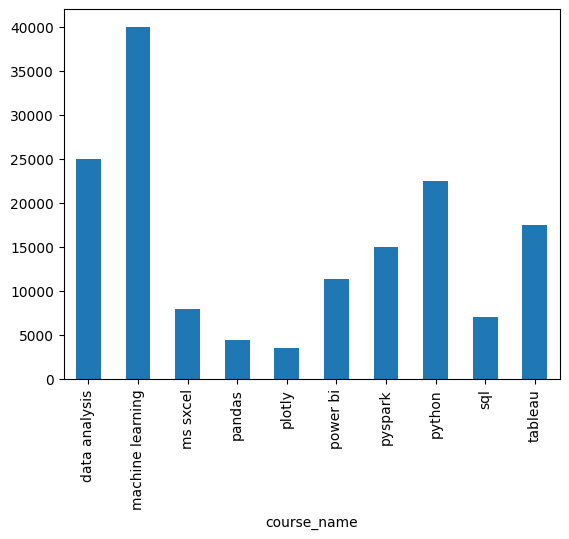

In [65]:
# 4. Plot bar chart for revenue/course
regs.merge(courses,how='inner',on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [68]:
# 5. find students who enrolled in both the months

common_SID = np.intersect1d(dec['student_id'], nov['student_id'])
students[students['student_id'].isin(common_SID)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [71]:
# 6. find course that got no enrollment
course_id_list = np.setdiff1d(courses['course_id'],regs['course_id'])

courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [73]:
# 7. find students who did not enroll into any courses
student_idd = np.setdiff1d(students['student_id'],regs['student_id'])

students[students['student_id'].isin(student_idd)]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11
0,26,Zain,28
1,27,Usman,26
2,28,hunain,17


In [ ]:
# 8. Print student name -> partner name for all enrolled students
# self join we nee to use left_on or rigt_on when performing  self join
students.merge(students,how='inner',left_on='partner',right_on='partner')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Kailash Harjo
1,Esha Butala,Esha Butala
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Marlo Dugal
4,Kusum Bahri,Kusum Bahri
5,Lakshmi Contractor,Lakshmi Contractor
6,Tarun Thaker,Tarun Thaker
7,Radheshyam Dey,Radheshyam Dey
8,Nitika Chatterjee,Nitika Chatterjee
9,Aayushman Sant,Aayushman Sant


In [90]:
# 9. find top 3 students who did most number enrollments

regs.merge(students,how='inner',on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64

In [93]:
# 10. find top 3 students who spent most amount of money on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().head(3)


student_id  name          
1           Kailash Harjo     7596
2           Esha Butala       2499
3           Parveen Bhalla    7498
Name: price, dtype: int64

In [94]:
# Alternate syntax for merge
# students.merge(regs)

pd.merge(students,regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [104]:
# IPL PROBLEMS

# find the top 3 stadiums  with highest sixes/match ratio
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [105]:
delivery  

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [108]:
temp = delivery.merge(matches,left_on='match_id',right_on='id')

In [111]:
six_df = temp[temp['batsman_runs'] == 6]

In [120]:
# stadium -->> Sixes
num_six = six_df.groupby('venue')['venue'].count()

In [122]:
num_matches  =  matches['venue'].value_counts()

In [124]:
(num_six/num_matches).sort_values(ascending=False).head(10)

venue
Holkar Cricket Stadium                                 17.600000
M Chinnaswamy Stadium                                  13.227273
Sharjah Cricket Stadium                                12.666667
Himachal Pradesh Cricket Association Stadium           12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11.727273
Wankhede Stadium                                       11.526316
De Beers Diamond Oval                                  11.333333
Maharashtra Cricket Association Stadium                11.266667
JSCA International Stadium Complex                     10.857143
Sardar Patel Stadium, Motera                           10.833333
dtype: float64

In [130]:
# find orange cap holder for all the ipl seasos # temp is allready mergre we merge it

temp.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season',ascending=True)

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
